In [186]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [187]:
train = pd.read_csv(r"../data/raw/train.csv")
store = pd.read_csv(r"../data/raw/store.csv")

C:\Users\HP\AppData\Local\Temp\ipykernel_25348\1944415905.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(r"../data/raw/train.csv")


In [188]:
train["Date"] = pd.to_datetime(train["Date"])

In [189]:
train["StateHoliday"] = train["StateHoliday"].astype(str)

In [190]:
df = train.merge(store,on="Store",how="left")
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,Id,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-17,4852,519,1,1,0,0,303445,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-17,4518,495,1,1,0,1,959585,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-17,6679,673,1,1,0,1,739744,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-17,10514,1343,1,1,0,1,864001,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-17,4355,513,1,1,0,1,981931,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [191]:
df_clean = df.copy()

In [192]:
missing = pd.DataFrame({
    "Missing Count": df_clean.isnull().sum(),
    "Missing %": round(df_clean.isnull().mean()*100,2)
})

missing = missing[missing["Missing Count"]>0].sort_values("Missing %",ascending=False)

missing

,Missing Count,Missing %
Promo2SinceYear,500415,49.96
Promo2SinceWeek,500415,49.96
PromoInterval,500415,49.96
CompetitionOpenSinceMonth,318392,31.79
CompetitionOpenSinceYear,318392,31.79
CompetitionDistance,2600,0.26


In [193]:
df_clean.isnull().sum()

Store                             0
DayOfWeek                         0
Date                              0
Sales                             0
Customers                         0
Open                              0
Promo                             0
StateHoliday                      0
SchoolHoliday                     0
Id                                0
StoreType                         0
Assortment                        0
CompetitionDistance            2600
CompetitionOpenSinceMonth    318392
CompetitionOpenSinceYear     318392
Promo2                            0
Promo2SinceWeek              500415
Promo2SinceYear              500415
PromoInterval                500415
dtype: int64

In [194]:
df_clean["CompetitionDistance"] = df_clean["CompetitionDistance"].fillna(
    df_clean["CompetitionDistance"].median()
)

In [195]:
df_clean['CompetitionOpenSinceMonth'] = df_clean['CompetitionOpenSinceMonth'].fillna(0)

In [196]:
df_clean['CompetitionOpenSinceYear'] = df_clean['CompetitionOpenSinceYear'].fillna(0)

In [197]:
df_clean['Promo2SinceWeek'] = df_clean['Promo2SinceWeek'].fillna(0)
df_clean['Promo2SinceYear'] = df_clean['Promo2SinceYear'].fillna(0)

In [198]:
df_clean["PromoInterval"] = df_clean["PromoInterval"].fillna("No Promo")

In [199]:
df_clean.isnull().sum()

Store                        0
DayOfWeek                    0
Date                         0
Sales                        0
Customers                    0
Open                         0
Promo                        0
StateHoliday                 0
SchoolHoliday                0
Id                           0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

In [200]:
df_clean.duplicated().sum()

np.int64(0)

In [201]:
for col in ["StoreType","Assortment","StateHoliday"]:
    print(col)
    print(df_clean[col].unique())
    print("-"*40)

StoreType
['c' 'a' 'd' 'b']
----------------------------------------
Assortment
['a' 'c' 'b']
----------------------------------------
StateHoliday
['0' 'a' 'b' 'c']
----------------------------------------


In [202]:
df_clean["Sales"].describe()

count    1.001599e+06
mean     5.770573e+03
std      3.852568e+03
min      0.000000e+00
25%      3.722000e+03
50%      5.741000e+03
75%      7.854000e+03
max      4.155100e+04
Name: Sales, dtype: float64

In [203]:
df_clean[df["Open"]==0]["Sales"].describe()

count    170627.0
mean          0.0
std           0.0
min           0.0
25%           0.0
50%           0.0
75%           0.0
max           0.0
Name: Sales, dtype: float64

In [204]:
df_clean = df_clean[
    (df_clean["Open"] == 1) &
    (df_clean["Sales"] > 0)
]

In [205]:
df_clean.shape

(830918, 19)

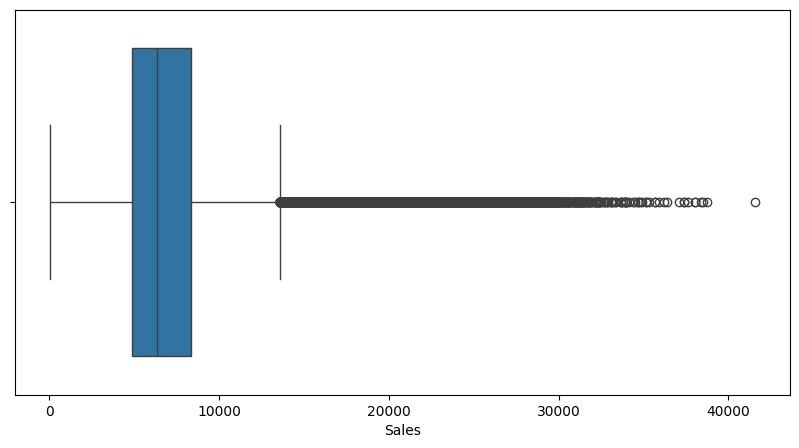

In [206]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean["Sales"])
plt.show()

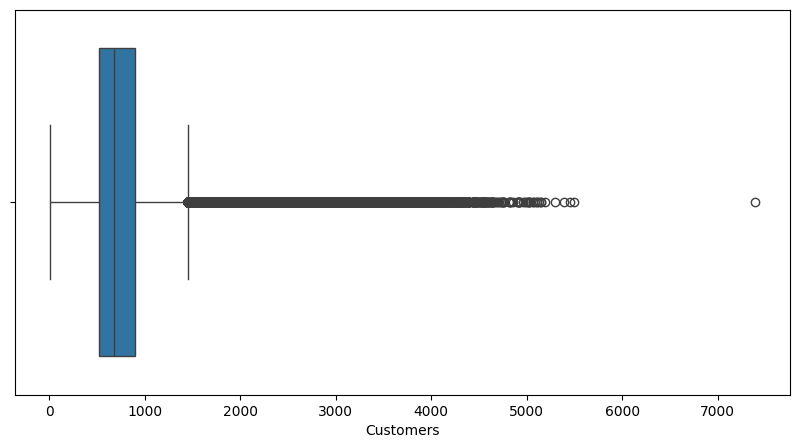

In [207]:
plt.figure(figsize=(10,5))
sns.boxplot(x=df_clean["Customers"])
plt.show()

In [208]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 830918 entries, 0 to 1001580
Data columns (total 19 columns):
 #   Column                     Non-Null Count   Dtype         
---  ------                     --------------   -----         
 0   Store                      830918 non-null  int64         
 1   DayOfWeek                  830918 non-null  int64         
 2   Date                       830918 non-null  datetime64[ns]
 3   Sales                      830918 non-null  int64         
 4   Customers                  830918 non-null  int64         
 5   Open                       830918 non-null  int64         
 6   Promo                      830918 non-null  int64         
 7   StateHoliday               830918 non-null  object        
 8   SchoolHoliday              830918 non-null  int64         
 9   Id                         830918 non-null  int64         
 10  StoreType                  830918 non-null  object        
 11  Assortment                 830918 non-null  object      

In [209]:
df_clean.to_csv(
    "../data/processed/clean_sales.csv",
    index=False
)

## Data Cleaning Summary

| Issue | Treatment | Reason |
|---|---|---|
| CompetitionDistance | Filled with median | Skewed numerical feature |
| CompetitionOpenSinceMonth | Filled with 0 | No competitor information available |
| CompetitionOpenSinceYear | Filled with 0 | No competitor information available |
| Promo2SinceWeek | Filled with 0 | Store not in Promo2 program |
| Promo2SinceYear | Filled with 0 | Store not in Promo2 program |
| PromoInterval | Filled with "No Promo" | Store has no recurring promotion |
| Duplicate rows | Removed (if any) | Prevent duplicate influence |
| Closed stores | Removed | Focus on forecasting operational stores |
| Outliers | Retained | Reflect real business events like holidays and promotions |